In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
from collections import Counter

# Global Configuration Parameters
WINDOW_SIZE = 250
STEP_SIZE = 50
BATCH_SIZE = 128
NUM_CLASSES = 10
TEST_SIZE = 0.20
VAL_SIZE = 0.20
RANDOM_STATE = 42
EPOCHS = 20

LABELED_DIR = Path("./filtered/csv_labeled").resolve()


def load_subject_dependent_split(
    labeled_dir: Path,
    window_size=250,
    step_size=50,
    test_size=0.20,
    val_size=0.20,
    random_state=42,
):
    all_files = sorted(labeled_dir.glob("*.csv"))
    if not all_files:
        raise FileNotFoundError(f"No CSV files found in {labeled_dir}")

    X_all, y_all = [], []

    for file_path in all_files:
        print(f"Processing subject file: {file_path.name}")
        df = pd.read_csv(file_path, header=None)
        data = df.values

        num_windows = (len(data) - window_size) // step_size + 1
        for i in range(num_windows):
            start = i * step_size
            end = start + window_size

            window_labels = data[start:end, 4]
            if len(np.unique(window_labels)) != 1:
                continue

            X_all.append(data[start:end, 0:4].astype(np.float32))
            y_all.append(int(data[start, 4]))

    X_all = np.array(X_all, dtype=np.float32)
    y_all = np.array(y_all, dtype=np.int64)

    if X_all.size == 0:
        raise ValueError("No windows were extracted from the labeled CSV files.")

    print("\nRaw unique labels:", np.unique(y_all))
    if y_all.min() == 1:
        print("Labels are 1-indexed! Shifting to 0-indexed...")
        y_all -= 1
    print("Corrected unique labels:", np.unique(y_all))

    rng = np.random.default_rng(random_state)
    indices = rng.permutation(len(X_all))
    X_all = X_all[indices]
    y_all = y_all[indices]

    n_total = len(X_all)
    n_test = int(n_total * test_size)
    n_val = int(n_total * val_size)
    n_train = n_total - n_val - n_test

    X_train = X_all[:n_train]
    y_train = y_all[:n_train]
    X_val = X_all[n_train:n_train + n_val]
    y_val = y_all[n_train:n_train + n_val]
    X_test = X_all[n_train + n_val:]
    y_test = y_all[n_train + n_val:]

    global_mean = X_train.mean(axis=(0, 1), keepdims=True)
    global_std = X_train.std(axis=(0, 1), keepdims=True)
    global_std[global_std == 0] = 1e-8

    X_train = (X_train - global_mean) / global_std
    X_val = (X_val - global_mean) / global_std
    X_test = (X_test - global_mean) / global_std

    print("\n--- Subject-Dependent Split Summary ---")
    print(f"X_train shape : {X_train.shape}")
    print(f"X_val shape   : {X_val.shape}")
    print(f"X_test shape  : {X_test.shape}")
    print(f"Train class dist : {dict(sorted(Counter(y_train.tolist()).items()))}")
    print(f"Val class dist   : {dict(sorted(Counter(y_val.tolist()).items()))}")
    print(f"Test class dist  : {dict(sorted(Counter(y_test.tolist()).items()))}")

    return X_train, y_train, X_val, y_val, X_test, y_test


# Load the pooled subject-dependent dataset
X_train, y_train, X_val, y_val, X_test, y_test = load_subject_dependent_split(
    LABELED_DIR, WINDOW_SIZE, STEP_SIZE, TEST_SIZE, VAL_SIZE, RANDOM_STATE
)

Processing subject file: 10_filtered.csv
Processing subject file: 11_filtered.csv
Processing subject file: 12_filtered.csv
Processing subject file: 13_filtered.csv
Processing subject file: 14_filtered.csv
Processing subject file: 15_filtered.csv
Processing subject file: 16_filtered.csv
Processing subject file: 17_filtered.csv
Processing subject file: 18_filtered.csv
Processing subject file: 19_filtered.csv
Processing subject file: 1_filtered.csv
Processing subject file: 20_filtered.csv
Processing subject file: 21_filtered.csv
Processing subject file: 22_filtered.csv
Processing subject file: 23_filtered.csv
Processing subject file: 24_filtered.csv
Processing subject file: 25_filtered.csv
Processing subject file: 26_filtered.csv
Processing subject file: 27_filtered.csv
Processing subject file: 28_filtered.csv
Processing subject file: 29_filtered.csv
Processing subject file: 2_filtered.csv
Processing subject file: 30_filtered.csv
Processing subject file: 31_filtered.csv
Processing subject

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

# Convert arrays into PyTorch datasets
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

# Class-balanced loss
counts = np.bincount(y_train)
weights = 1.0 / counts.astype(np.float32)
weights = weights / weights.sum() * NUM_CLASSES
class_weights = torch.FloatTensor(weights)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu')))

# Training device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Optimizer and scheduler



Train batches: 4763 | Val batches: 1588 | Test batches: 1588
Using device: cuda


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

# Convert arrays into PyTorch datasets and loaders
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 4763 | Val batches: 1588 | Test batches: 1588


In [5]:
class CNNBiLSTMAttention(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, num_classes=10):
        super(CNNBiLSTMAttention, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=4, out_channels=32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU()
        )
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=hidden_dim,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.3
        )
        self.attention_linear = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.attention_query = nn.Linear(hidden_dim * 2, 1, bias=False)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        energy = torch.tanh(self.attention_linear(lstm_out))
        attention_scores = self.attention_query(energy)
        attention_weights = F.softmax(attention_scores, dim=1)
        context_vector = torch.sum(attention_weights * lstm_out, dim=1)
        return self.classifier(context_vector)

# Build model and verify output shape
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNBiLSTMAttention(input_dim=4, hidden_dim=64, num_classes=NUM_CLASSES).to(device)
print(model)
dummy = torch.randn(8, 250, 4).to(device)
out = model(dummy)
print(f"Output shape: {out.shape}")

CNNBiLSTMAttention(
  (cnn): Sequential(
    (0): Conv1d(4, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention_linear): Linear(in_features=128, out_features=128, bias=True)
  (attention_query): Linear(in_features=128, out_features=1, bias=False)
  (classifier): Sequential

In [8]:
# Class-weighted loss for any residual imbalance
counts = np.bincount(y_train)
weights = 1.0 / counts.astype(np.float32)
weights = weights / weights.sum() * NUM_CLASSES
class_weights = torch.FloatTensor(weights).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5, verbose=True
)

def check_pred_distribution(model, loader, device, label=""):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch_X, _ in loader:
            preds = model(batch_X.to(device)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
    print(f"  [{label}] Pred dist: {dict(sorted(Counter(all_preds).items()))}")

best_val_acc = 0.0
patience_counter = 0
EARLY_STOP_PATIENCE = 10

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Train]", unit="batch")
    for batch_X, batch_y in train_bar:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()

        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{(predicted == batch_y).sum().item() / batch_y.size(0) * 100:.2f}%",
            "lr": f"{optimizer.param_groups[0]['lr']:.6f}"
        })

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [Val  ]", unit="batch", leave=False)
    with torch.no_grad():
        for batch_X, batch_y in val_bar:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()
            val_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    scheduler.step(epoch_val_acc)

    print(f"Summary -> Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f}")

    if (epoch + 1) % 5 == 0:
        print("  Diagnostics:")
        check_pred_distribution(model, train_loader, device, "Train")
        check_pred_distribution(model, val_loader, device, "Val  ")

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_sd_bilstm_emg.pth")
        print(f"--> ✅ Saved best model! Val Acc: {best_val_acc:.2f}%")
    else:
        patience_counter += 1
        print(f"    No improvement. Patience: {patience_counter}/{EARLY_STOP_PATIENCE}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n⛔ Early stopping at epoch {epoch+1}!")
        break

    print("-" * 80)

model.load_state_dict(torch.load("best_sd_bilstm_emg.pth"))
print(f"\n✅ Training complete! Best Val Acc: {best_val_acc:.2f}%")

c:\Users\Asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "
Epoch 01/20 [Train]: 100%|██████████| 4763/4763 [01:38<00:00, 48.33batch/s, loss=1.8024, acc=23.44%, lr=0.001000]


Summary -> Train Loss: 1.8524 | Train Acc: 26.95% | Val Loss: 1.7836 | Val Acc: 29.10% | LR: 0.001000
--> ✅ Saved best model! Val Acc: 29.10%
--------------------------------------------------------------------------------


Epoch 02/20 [Train]: 100%|██████████| 4763/4763 [01:24<00:00, 56.25batch/s, loss=1.7271, acc=28.12%, lr=0.001000]


Summary -> Train Loss: 1.7477 | Train Acc: 29.99% | Val Loss: 1.7044 | Val Acc: 31.40% | LR: 0.001000
--> ✅ Saved best model! Val Acc: 31.40%
--------------------------------------------------------------------------------


Epoch 03/20 [Train]: 100%|██████████| 4763/4763 [01:25<00:00, 55.54batch/s, loss=1.6296, acc=37.50%, lr=0.001000]


...

Summary -> Train Loss: 1.5008 | Train Acc: 38.62% | Val Loss: 1.4730 | Val Acc: 39.90% | LR: 0.001000
--> ✅ Saved best model! Val Acc: 39.90%
--------------------------------------------------------------------------------


Epoch 19/20 [Train]: 100%|██████████| 4763/4763 [02:20<00:00, 33.90batch/s, loss=1.3739, acc=54.69%, lr=0.001000]


Summary -> Train Loss: 1.4974 | Train Acc: 38.77% | Val Loss: 1.4972 | Val Acc: 38.53% | LR: 0.001000
    No improvement. Patience: 1/10
--------------------------------------------------------------------------------


Epoch 20/20 [Train]: 100%|██████████| 4763/4763 [02:30<00:00, 31.61batch/s, loss=1.4127, acc=40.62%, lr=0.001000]


Summary -> Train Loss: 1.4945 | Train Acc: 38.78% | Val Loss: 1.5384 | Val Acc: 38.03% | LR: 0.001000
  Diagnostics:
  [Train] Pred dist: {0: 100622, 1: 63453, 2: 75793, 3: 35487, 4: 67022, 5: 51582, 6: 49205, 7: 56493, 8: 68710, 9: 41233}
  [Val  ] Pred dist: {0: 33379, 1: 21295, 2: 25147, 3: 11818, 4: 22324, 5: 17329, 6: 16268, 7: 18885, 8: 23076, 9: 13679}
    No improvement. Patience: 2/10
--------------------------------------------------------------------------------

✅ Training complete! Best Val Acc: 39.90%


# Reload the model and train for 10 more epochs


In [10]:
import torch
import torch.nn as nn
from tqdm import tqdm
from collections import Counter

# 1. Load the optimal weights from the first 20 epochs
print("Loading pre-trained weights from disk...")
model.load_state_dict(torch.load("best_sd_bilstm_emg.pth"))
model.to(device)

# 2. Re-initialize Optimizer and Scheduler
# Using a slightly smaller LR (5e-4) since the model is already converged nicely
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5, verbose=True
)

# 3. Continuation Setup
ADDITIONAL_EPOCHS = 30
EARLY_STOP_PATIENCE = 10
patience_counter = 0

print("\n--- Running Baseline Evaluation ---")
# We MUST evaluate the loaded model first to set the `best_val_acc` threshold.
# If we don't do this, epoch 1 might save a worse model over your good file!
model.eval()
correct_baseline = 0
total_baseline = 0
with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        total_baseline += batch_y.size(0)
        correct_baseline += (predicted == batch_y).sum().item()

best_val_acc = (correct_baseline / total_baseline) * 100
print(f"Baseline Validation Accuracy locked at: {best_val_acc:.2f}%")
print("Starting additional 30 epochs...\n")
print("-" * 80)

# 4. The Phase 2 Training Loop
for epoch in range(ADDITIONAL_EPOCHS):
    # --- TRAINING ---
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # Label the epoch visually as 21-50
    display_epoch = epoch + 21 
    train_bar = tqdm(train_loader, desc=f"Epoch {display_epoch:02d}/{20 + ADDITIONAL_EPOCHS} [Train]", unit="batch")
    
    for batch_X, batch_y in train_bar:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * batch_X.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()

        train_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{(predicted == batch_y).sum().item() / batch_y.size(0) * 100:.2f}%",
            "lr": f"{optimizer.param_groups[0]['lr']:.6f}"
        })

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100

    # --- VALIDATION ---
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    val_bar = tqdm(val_loader, desc=f"Epoch {display_epoch:02d}/{20 + ADDITIONAL_EPOCHS} [Val  ]", unit="batch", leave=False)
    
    with torch.no_grad():
        for batch_X, batch_y in val_bar:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()
            val_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    # Step the learning rate scheduler based on validation accuracy
    scheduler.step(epoch_val_acc)

    print(f"Summary -> Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}% | LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Diagnostics every 5 epochs
    if (epoch + 1) % 5 == 0:
        print("  Diagnostics:")
        check_pred_distribution(model, train_loader, device, "Train")
        check_pred_distribution(model, val_loader, device, "Val  ")

    # --- CHECKPOINTING ---
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_sd_bilstm_emg.pth")
        print(f"--> ✅ Saved NEW best model! Val Acc: {best_val_acc:.2f}%")
    else:
        patience_counter += 1
        print(f"    No improvement. Patience: {patience_counter}/{EARLY_STOP_PATIENCE}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n⛔ Early stopping triggered at actual epoch {display_epoch}!")
        break

    print("-" * 80)

# Final Reload
model.load_state_dict(torch.load("best_sd_bilstm_emg.pth"))
print(f"\n✅ Phase 2 Training complete! Ultimate Best Val Acc: {best_val_acc:.2f}%")

Loading pre-trained weights from disk...

--- Running Baseline Evaluation ---
Baseline Validation Accuracy locked at: 39.90%
Starting additional 30 epochs...

--------------------------------------------------------------------------------


Epoch 21/50 [Train]: 100%|██████████| 4763/4763 [02:27<00:00, 32.33batch/s, loss=1.5752, acc=29.69%, lr=0.000500]


Summary -> Train Loss: 1.4463 | Train Acc: 40.55% | Val Loss: 1.4199 | Val Acc: 41.41% | LR: 0.000500
--> ✅ Saved NEW best model! Val Acc: 41.41%
--------------------------------------------------------------------------------


Epoch 22/50 [Train]: 100%|██████████| 4763/4763 [02:34<00:00, 30.79batch/s, loss=1.4347, acc=37.50%, lr=0.000500]


Summary -> Train Loss: 1.4376 | Train Acc: 40.96% | Val Loss: 1.5396 | Val Acc: 38.62% | LR: 0.000500
    No improvement. Patience: 1/10
--------------------------------------------------------------------------------


...

Summary -> Train Loss: 1.3375 | Train Acc: 45.17% | Val Loss: 1.3409 | Val Acc: 45.03% | LR: 0.000063
    No improvement. Patience: 2/10
--------------------------------------------------------------------------------


Epoch 49/50 [Train]: 100%|██████████| 4763/4763 [01:25<00:00, 55.39batch/s, loss=1.2242, acc=51.56%, lr=0.000063]


Summary -> Train Loss: 1.3380 | Train Acc: 45.23% | Val Loss: 1.3442 | Val Acc: 44.81% | LR: 0.000063
    No improvement. Patience: 3/10
--------------------------------------------------------------------------------


Epoch 50/50 [Train]: 100%|██████████| 4763/4763 [01:27<00:00, 54.58batch/s, loss=1.3399, acc=42.19%, lr=0.000063]


Summary -> Train Loss: 1.3390 | Train Acc: 45.29% | Val Loss: 1.3330 | Val Acc: 45.24% | LR: 0.000031
  Diagnostics:
  [Train] Pred dist: {0: 70225, 1: 65583, 2: 58483, 3: 49355, 4: 65632, 5: 53784, 6: 68624, 7: 53875, 8: 67729, 9: 56310}
  [Val  ] Pred dist: {0: 23282, 1: 21974, 2: 19547, 3: 16191, 4: 21935, 5: 17978, 6: 22885, 7: 17969, 8: 22760, 9: 18679}
    No improvement. Patience: 4/10
--------------------------------------------------------------------------------

✅ Phase 2 Training complete! Ultimate Best Val Acc: 46.06%


In [12]:
# Load the best weights verified by your validation split
model.load_state_dict(torch.load("best_sd_bilstm_emg.pth"))
model.eval()

correct_test = 0
total_test = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        _, predicted = torch.max(outputs, 1)
        total_test += batch_y.size(0)
        correct_test += (predicted == batch_y).sum().item()

final_test_acc = (correct_test / total_test) * 100
print("====================================================")
print(f"FINAL SUB-INDEPENDENT ACCURACY ON TEST SUBJECTS: {final_test_acc:.2f}%")
print("====================================================")

FINAL SUB-INDEPENDENT ACCURACY ON TEST SUBJECTS: 46.05%


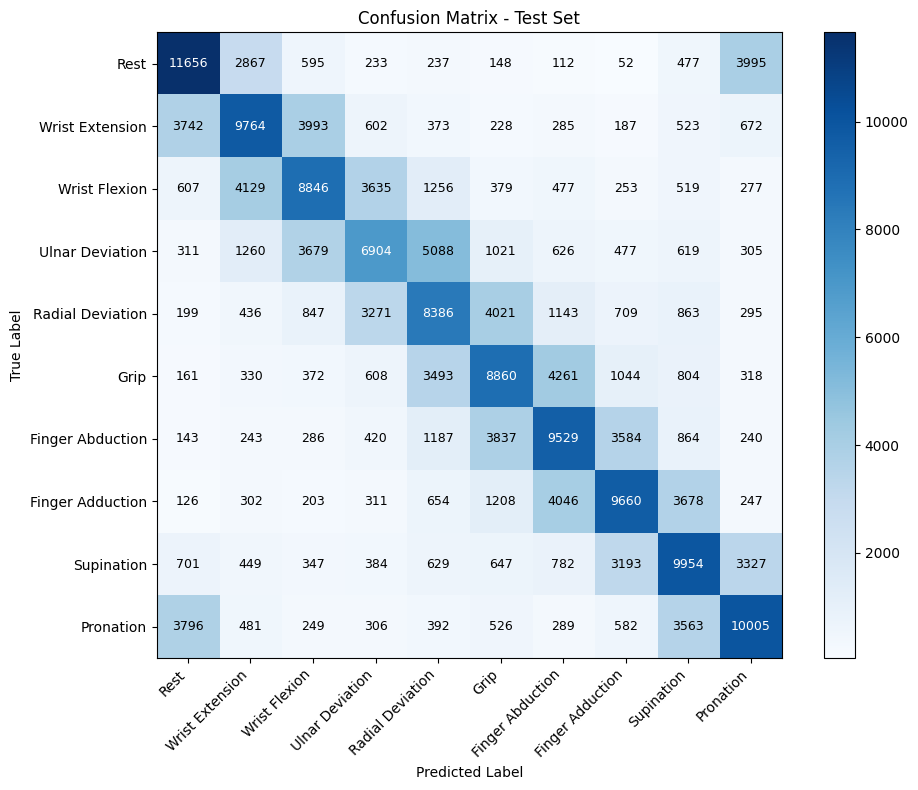

In [13]:
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "Rest",
    "Wrist Extension",
    "Wrist Flexion",
    "Ulnar Deviation",
    "Radial Deviation",
    "Grip",
    "Finger Abduction",
    "Finger Adduction",
    "Supination",
    "Pronation",
]

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(batch_y.numpy())

num_classes = NUM_CLASSES
cm = np.zeros((num_classes, num_classes), dtype=np.int64)
for true_label, pred_label in zip(all_targets, all_preds):
    cm[true_label, pred_label] += 1

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.colorbar()

indices = np.arange(num_classes)
plt.xticks(indices, class_names, rotation=45, ha="right")
plt.yticks(indices, class_names)

threshold = cm.max() / 2.0 if cm.max() > 0 else 0
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=9,
        )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()
